# Ridge & Lasso Regression — Calories Burned Prediction

This notebook trains and evaluates Ridge and Lasso regression models on the **Gym Members Exercise Tracking** dataset.

**Input files expected (produced by Preprocessing.ipynb):**
- `X_train_prepared.csv`
- `y_train_prepared.csv`
- `X_test_processed.csv`
- `y_test.csv`

### Imports

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold

### Load Preprocessed Data

In [20]:
X_train = pd.read_csv("X_train_prepared.csv", index_col=0)
y_train = pd.read_csv("y_train_prepared.csv", index_col=0).squeeze("columns")

X_test  = pd.read_csv("X_test_processed.csv", index_col=0)
y_test  = pd.read_csv("y_test.csv", index_col=0).squeeze("columns")

print("Train features:", X_train.shape)
print("Train target :", y_train.shape)
print("Test  features:", X_test.shape)
print("Test  target :", y_test.shape)

Train features: (747, 18)
Train target : (747,)
Test  features: (195, 18)
Test  target : (195,)


### Cross-Validation Setup

In [21]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

## 1. Ridge Regression

### 1a. Hyperparameter Tuning (RidgeCV)

In [22]:
alphas_ridge = np.logspace(-3, 4, 200)  # 0.001 → 10,000

ridge_cv = RidgeCV(alphas=alphas_ridge, cv=kf, scoring="neg_mean_squared_error")
ridge_cv.fit(X_train, y_train)

best_alpha_ridge = ridge_cv.alpha_
print(f"Best Ridge alpha: {best_alpha_ridge:.6f}")

Best Ridge alpha: 0.977124


### 1b. Train Final Ridge Model

In [23]:
ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(X_train, y_train)

print(f"Ridge model trained with alpha = {best_alpha_ridge:.6f}")

Ridge model trained with alpha = 0.977124


### 1c. Evaluate Ridge Model

In [8]:
y_pred_ridge = ridge.predict(X_test)

mse_ridge  = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge   = r2_score(y_test, y_pred_ridge)

print("=== Ridge Regression — Test Set ===")
print(f"  MSE  : {mse_ridge:,.2f}")
print(f"  RMSE : {rmse_ridge:,.2f}")
print(f"  MAE  : {mae_ridge:,.2f}")
print(f"  R²   : {r2_ridge:.4f}")

=== Ridge Regression — Test Set ===
  MSE  : 1,695.43
  RMSE : 41.18
  MAE  : 30.66
  R²   : 0.9797


### 1d. 5-Fold Cross-Validation Scores (Ridge)

In [9]:
cv_r2_ridge = cross_val_score(ridge, X_train, y_train, cv=kf, scoring="r2")
print(f"Ridge CV R²  : {cv_r2_ridge}")
print(f"Mean CV R²   : {cv_r2_ridge.mean():.4f} ± {cv_r2_ridge.std():.4f}")

Ridge CV R²  : [0.98058617 0.97040796 0.9793238  0.97745016 0.98338068]
Mean CV R²   : 0.9782 ± 0.0044


---
## 2. Lasso Regression

### 2a. Hyperparameter Tuning (LassoCV)

In [10]:
alphas_lasso = np.logspace(-3, 3, 200)  # 0.001 → 1,000

lasso_cv = LassoCV(alphas=alphas_lasso, cv=kf, max_iter=10_000, random_state=42)
lasso_cv.fit(X_train, y_train)

best_alpha_lasso = lasso_cv.alpha_
print(f"Best Lasso alpha: {best_alpha_lasso:.6f}")

Best Lasso alpha: 0.554266


### 2b. Train Final Lasso Model

In [11]:
lasso = Lasso(alpha=best_alpha_lasso, max_iter=10_000)
lasso.fit(X_train, y_train)

print(f"Lasso model trained with alpha = {best_alpha_lasso:.6f}")
print(f"Non-zero coefficients: {(lasso.coef_ != 0).sum()} / {len(lasso.coef_)}")

Lasso model trained with alpha = 0.554266
Non-zero coefficients: 13 / 18


### 2c. Evaluate Lasso Model

In [12]:
y_pred_lasso = lasso.predict(X_test)

mse_lasso  = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso   = r2_score(y_test, y_pred_lasso)

print("=== Lasso Regression — Test Set ===")
print(f"  MSE  : {mse_lasso:,.2f}")
print(f"  RMSE : {rmse_lasso:,.2f}")
print(f"  MAE  : {mae_lasso:,.2f}")
print(f"  R²   : {r2_lasso:.4f}")

=== Lasso Regression — Test Set ===
  MSE  : 1,702.57
  RMSE : 41.26
  MAE  : 30.42
  R²   : 0.9796


### 2d. 5-Fold Cross-Validation Scores (Lasso)

In [13]:
cv_r2_lasso = cross_val_score(lasso, X_train, y_train, cv=kf, scoring="r2")
print(f"Lasso CV R²  : {cv_r2_lasso}")
print(f"Mean CV R²   : {cv_r2_lasso.mean():.4f} ± {cv_r2_lasso.std():.4f}")

Lasso CV R²  : [0.98075004 0.97055331 0.97931483 0.97727356 0.9838811 ]
Mean CV R²   : 0.9784 ± 0.0045


---
## 3. Model Comparison

In [14]:
results = pd.DataFrame({
    "Model": ["Ridge", "Lasso"],
    "Best Alpha": [best_alpha_ridge, best_alpha_lasso],
    "MSE": [mse_ridge, mse_lasso],
    "RMSE": [rmse_ridge, rmse_lasso],
    "MAE": [mae_ridge, mae_lasso],
    "R² (test)": [r2_ridge, r2_lasso],
    "Mean CV R²": [cv_r2_ridge.mean(), cv_r2_lasso.mean()],
})

results = results.set_index("Model")
print(results.to_string())

       Best Alpha          MSE       RMSE        MAE  R² (test)  Mean CV R²
Model                                                                      
Ridge    0.977124  1695.429400  41.175592  30.659491   0.979677    0.978230
Lasso    0.554266  1702.570831  41.262220  30.424751   0.979592    0.978355


---
## 4. Visualisations

### 4a. Predicted vs Actual

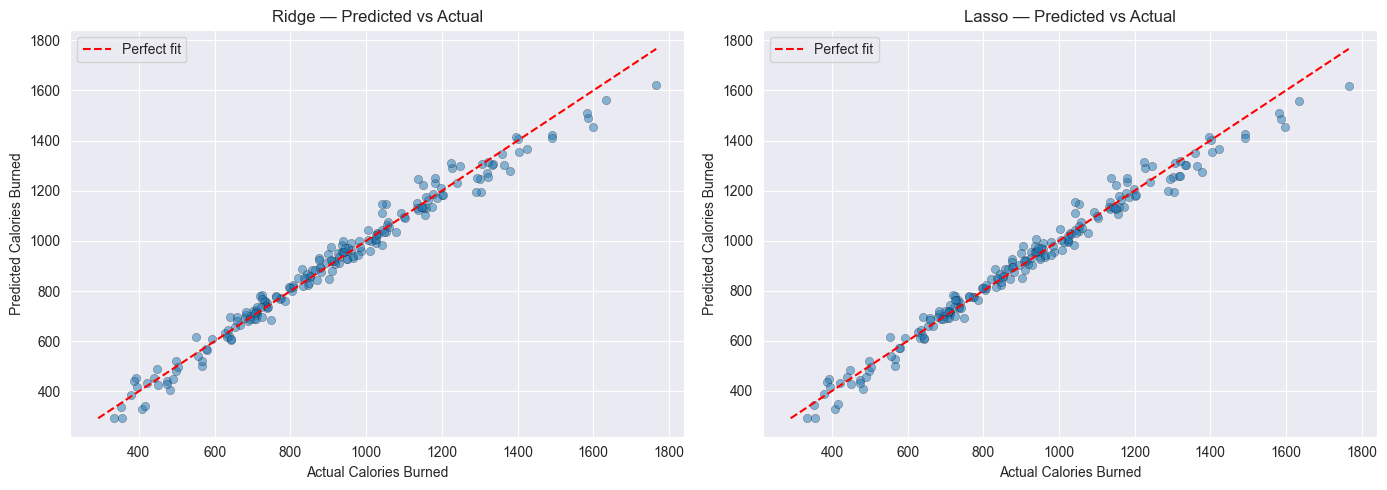

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, y_pred in zip(axes, ["Ridge", "Lasso"], [y_pred_ridge, y_pred_lasso]):
    ax.scatter(y_test, y_pred, alpha=0.5, edgecolors="k", linewidths=0.3)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", label="Perfect fit")
    ax.set_xlabel("Actual Calories Burned")
    ax.set_ylabel("Predicted Calories Burned")
    ax.set_title(f"{name} — Predicted vs Actual")
    ax.legend()

plt.tight_layout()
plt.show()

### 4b. Residual Plots

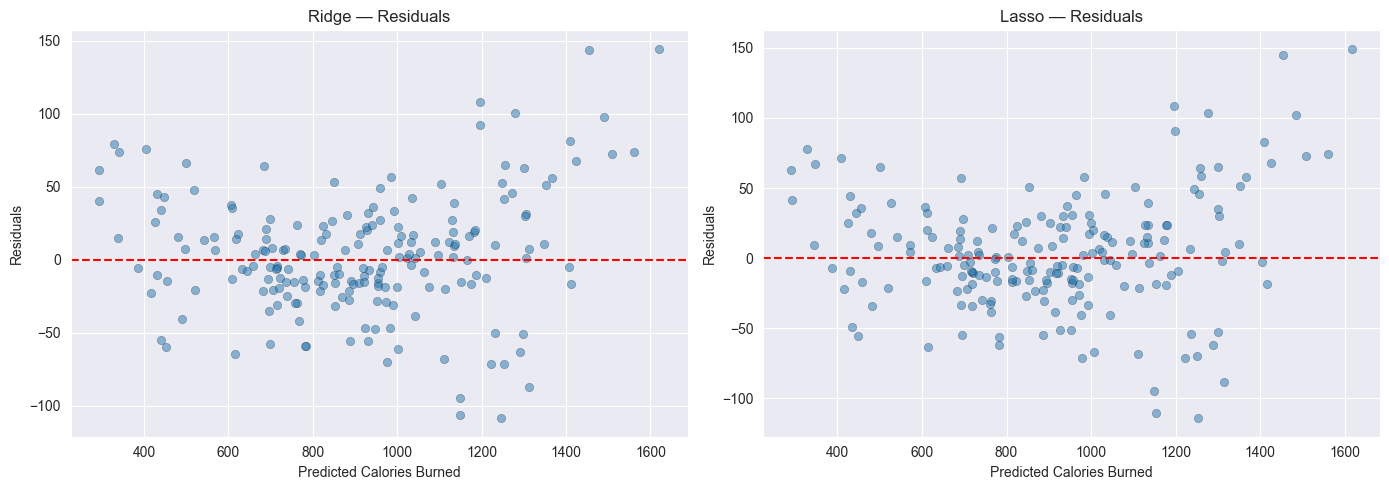

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, y_pred in zip(axes, ["Ridge", "Lasso"], [y_pred_ridge, y_pred_lasso]):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.5, edgecolors="k", linewidths=0.3)
    ax.axhline(0, color="r", linestyle="--")
    ax.set_xlabel("Predicted Calories Burned")
    ax.set_ylabel("Residuals")
    ax.set_title(f"{name} — Residuals")

plt.tight_layout()
plt.show()

### 4c. Coefficient Comparison

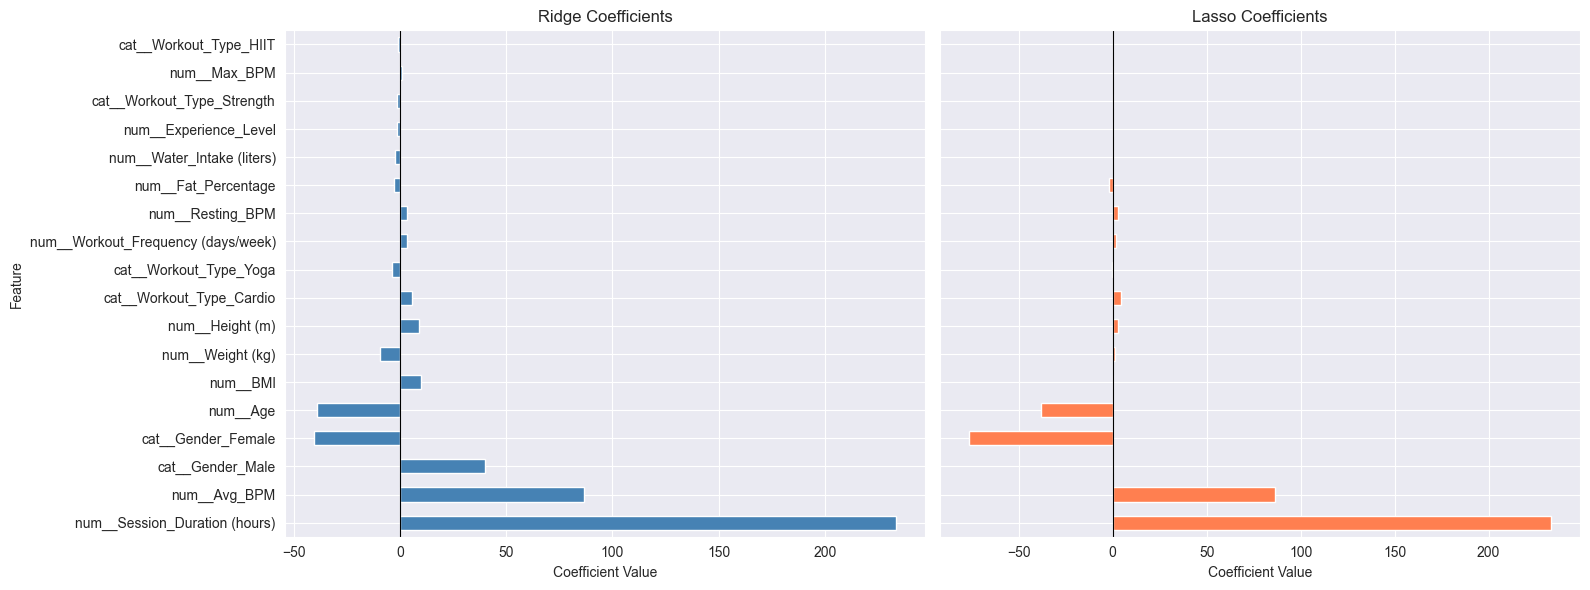

In [17]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_,
}).set_index("Feature")

coef_df = coef_df.reindex(coef_df["Ridge"].abs().sort_values(ascending=False).index)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, col, color in zip(axes, ["Ridge", "Lasso"], ["steelblue", "coral"]):
    coef_df[col].plot(kind="barh", ax=ax, color=color)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{col} Coefficients")
    ax.set_xlabel("Coefficient Value")

plt.tight_layout()
plt.show()

### 4d. Lasso — Number of Non-Zero Coefficients vs Alpha

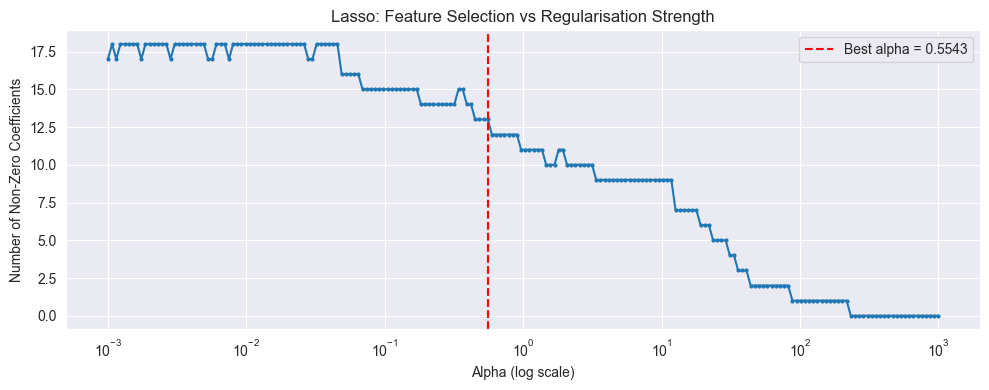

In [24]:
nonzero_counts = []
for a in alphas_lasso:
    m = Lasso(alpha=a, max_iter=10_000)
    m.fit(X_train, y_train)
    nonzero_counts.append((m.coef_ != 0).sum())

plt.figure(figsize=(10, 4))
plt.semilogx(alphas_lasso, nonzero_counts, marker="o", markersize=2)
plt.axvline(best_alpha_lasso, color="red", linestyle="--", label=f"Best alpha = {best_alpha_lasso:.4f}")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Number of Non-Zero Coefficients")
plt.title("Lasso: Feature Selection vs Regularisation Strength")
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Summary

| | Ridge | Lasso |
|---|---|---|
| **Regularisation** | L2 — shrinks all coefficients toward zero | L1 — drives some coefficients exactly to zero |
| **Feature selection** | No (keeps all features) | Yes (sparse solution) |
| **Best use case** | Many small effects, multicollinearity | Suspected irrelevant features |

Both models are tuned via cross-validation on the training set and evaluated on the held-out test set. The R² scores above tell you how well each explains the variance in `Calories_Burned`.